In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# =========================
# 1️⃣ Load Dataset
# =========================
df = pd.read_csv("honeypotLogsNew.csv")

# =========================
# 2️⃣ Clean Core Fields
# =========================
df['referrer'] = df['referrer'].fillna('')
df['userAgent'] = df['userAgent'].fillna('')
df['uniqueUserId'] = df['uniqueUserId'].fillna('unknown')

# =========================
# 3️⃣ Labels (FROZEN)
# =========================
df['Label'] = df['classification'].map({'human': 0, 'bot': 1})
df = df.dropna(subset=['Label'])

print("Label distribution:")
print(df['Label'].value_counts())

# =========================
# 4️⃣ SAFE Feature Engineering (NO LEAKS)
# =========================

# Text structure
df['userAgent_len'] = df['userAgent'].str.len()
df['referrer_present'] = (df['referrer'] != '').astype(int)

# Bot keywords (PASSIVE)
df['ua_bot_keyword'] = df['userAgent'].str.contains(
    'bot|crawl|spider|scrapy|wget|curl|python',
    case=False,
    na=False
).astype(int)

# Session timing (PASSIVE)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['night_activity'] = df['hour'].between(0, 5).astype(int)

# Frequency WITHOUT trap logic
df['ip_freq'] = df.groupby('ip')['ip'].transform('count')
df['uid_freq'] = df.groupby('uniqueUserId')['uniqueUserId'].transform('count')

# =========================
# 5️⃣ FINAL FEATURE MATRIX
# =========================
X = df[
    [
        'userAgent_len',
        'ua_bot_keyword',
        'referrer_present',
        'night_activity',
        'ip_freq',
        'uid_freq'
    ]
]

y = df['Label']

print("Final feature shape:", X.shape)

# =========================
# 6️⃣ ANTI-LEAKAGE SPLIT (CRITICAL)
# Group by user/session
# =========================
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=df['uniqueUserId'])
)

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# =========================
# 7️⃣ Train Model
# =========================
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# =========================
# 8️⃣ Evaluate
# =========================
y_pred = model.predict(X_test)

print("\n✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))
print("\n🧮 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Label distribution:
Label
0    1281
1     311
Name: count, dtype: int64
Final feature shape: (1592, 6)

✅ Accuracy: 0.9693593314763231

📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       319
           1       0.78      1.00      0.88        40

    accuracy                           0.97       359
   macro avg       0.89      0.98      0.93       359
weighted avg       0.98      0.97      0.97       359


🧮 Confusion Matrix:
[[308  11]
 [  0  40]]


ROC AUC Score: 0.9802115987460815


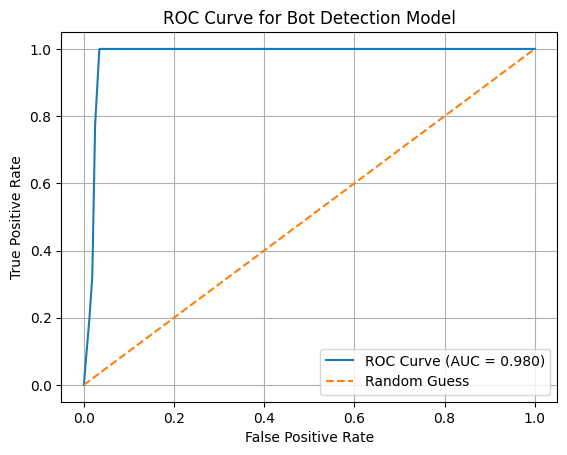

In [2]:
# =========================
# 9️⃣ ROC-AUC Curve
# =========================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get bot probability scores (NOT hard predictions)
y_prob = model.predict_proba(X_test)[:, 1]  # Probability of class "bot"

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("ROC AUC Score:", roc_auc)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Bot Detection Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


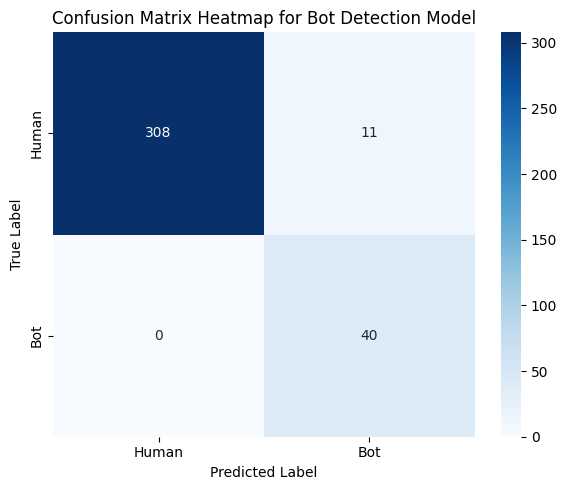

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Human", "Bot"],
    yticklabels=["Human", "Bot"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap for Bot Detection Model")
plt.tight_layout()
plt.show()


In [9]:
import joblib

joblib.dump(model, "bot_detection_model.joblib")


['bot_detection_model.joblib']

In [10]:
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "feature_columns.joblib")


['feature_columns.joblib']

In [11]:
import joblib
import pandas as pd
from datetime import datetime

model = joblib.load("bot_detection_model.joblib")
features = joblib.load("feature_columns.joblib")

def predict_bot(log):
    df = pd.DataFrame([log])

    df['userAgent_len'] = len(df['userAgent'][0])
    df['referrer_present'] = int(df['referrer'][0] != '')

    df['ua_bot_keyword'] = int(
        any(k in df['userAgent'][0].lower() for k in
            ['bot','crawl','spider','scrapy','wget','curl','python'])
    )

    hour = pd.to_datetime(df['timestamp'][0]).hour
    df['night_activity'] = int(0 <= hour <= 5)

    df['ip_freq'] = 1
    df['uid_freq'] = 1

    X = df[features]
    return model.predict(X)[0], model.predict_proba(X)[0]
